# Text analysis without trained models

Later in the course, we either use pre-trained models or models we trained ourselves for a corpus. Trained means, a statistical model is used for text analysis whose output depends on parameters that impact the model output. Before we use these more advanced techniques, we want to start with simpler approaches. Looking at our corpus, we want to aggregate the information in each document, usually by transforming it into a numerical representation. 

## Frequency based modeling

One of the easiest way to do this is to count the number of occurrences for every term in the document which ist listed in the lexicon. This approach is called bag-of-words which describes the fact we ignore the relationship of all words to each other and, hereby, loose semantic information. Let the number of documents be $n$ and the number of terms in the lexicon $d$, the corpus can be transformed to a document-term matrix $D$

$$
D = 
\begin{pmatrix}
x_{11} & x_{12} & \cdots & x_{1d} \\
\vdots & \vdots & \ddots & \vdots \\
x_{n1} & x_{n2} & \cdots & x_{nd} \\
\end{pmatrix}
$$

with $x_{ij}$ describing the number of term $j$ in document $i$. For larger corpora, $d$ is a large number so $D$ is a high-dimensional and, typically, sparse matrix which means the matrix has many zeros and only a few non-zero entries. A few options exist which can help dealing with this issue. One is the removal of stopwords. Other options are to exclude words with little and very high frequency or to exclude words with very little or high document occurrence. However, these measures need to be evaluated carefully, because sometimes words with little occurrence or frequency might provide more information than words with high occurrence of frequency. The bag-of-words approach can be conducted quite easily with the CountVectorizer class of the sklearn package. See a little demonstration in the following cells.

In [1]:
import sqlite3
import pandas as pd
from gensim.utils import simple_preprocess
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pylab as plt

# load Apple's 10-K filings
conn = sqlite3.connect("../data/dlta_texts.db")
sql_query = "SELECT * FROM filings;"
df_filings = pd.read_sql(sql_query, conn)
apple_filings = df_filings[df_filings.ticker == "AAPL"]
conn.close()
apple_filings.head(2)

,accessionNumber,filingDate,reportDate,acceptanceDateTime,act,form,fileNumber,filmNumber,items,size,isXBRL,isInlineXBRL,primaryDocument,primaryDocDescription,ticker,cik,text
0,0000320193-22-000108,2022-10-28,2022-09-24,2022-10-27T18:01:14.000Z,34,10-K,001-36743,221338448,,10332356,1,1,aapl-20220924.htm,10-K,AAPL,0000320193,10-K\n 1\n aapl-20220924.htm\n 10-K\n \n \n \n...
1,0000320193-21-000105,2021-10-29,2021-09-25,2021-10-28T18:04:28.000Z,34,10-K,001-36743,211359752,,10502096,1,1,aapl-20210925.htm,10-K,AAPL,0000320193,10-K\n 1\n aapl-20210925.htm\n 10-K\n \n \n \n...


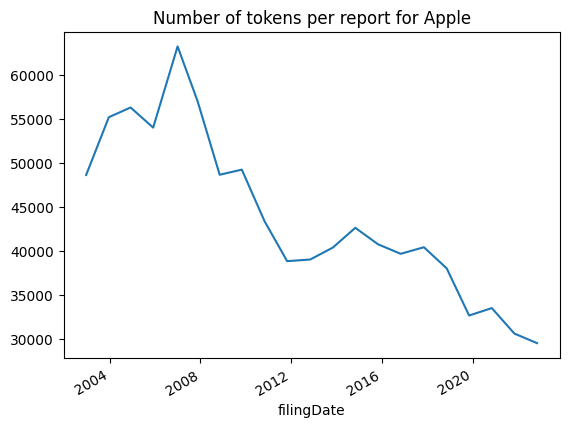

In [2]:
# a first check regarding the length of these reports
# import raw text
raw_reports = apple_filings.text.values
# preprocess each report
processed_reports = [simple_preprocess(report) for report in raw_reports]
# count the number of tokens for each report
nbr_words_per_report = [len(report) for report in processed_reports]
dates = pd.to_datetime(df_filings[df_filings.ticker == "AAPL"].filingDate)
words_per_report = pd.Series(index = dates, data = nbr_words_per_report)

# visualize the number of tokens per Apple report over time
fig, ax = plt.subplots()
words_per_report.plot(title = "Number of tokens per report for Apple", ax = ax)
plt.show()

Using the CountVectorizer with its default settings:

In [3]:
# create the bag-of-words with default settings
vectorizer = CountVectorizer(preprocessor = lambda x: " ".join(simple_preprocess(x)))
# the output is a sparse matrix, the first dimension are the number of reports, the second dimension is the number of terms
X = vectorizer.fit_transform(raw_reports)
# let us take a look at the first reports
feature_names = vectorizer.get_feature_names_out()
bow_default = pd.DataFrame(X.toarray(), index = dates, columns = feature_names)
bow_default.head()

,aac,aad,aapl,abandoned,abbett,abilities,ability,able,abnormal,abnormally,...,yo,york,yosemite,young,youtube,zayante,zero,zip,zones,zoom
filingDate,,,,,,,,,,,,,,,,,,,,,
2022-10-28,0,0,109,0,0,1,27,9,0,0,...,0,3,0,4,0,0,0,1,0,0
2021-10-29,0,0,130,0,0,1,26,10,0,0,...,0,2,0,3,0,0,0,1,0,0
2020-10-30,0,0,152,0,0,1,22,9,0,0,...,0,2,0,3,0,0,0,1,0,0
2019-10-31,0,0,116,0,0,1,19,9,0,0,...,0,2,0,3,0,0,0,1,0,0
2018-11-05,0,0,1,0,0,1,23,9,0,0,...,0,9,0,3,0,0,0,1,0,1


Using the CountVectorizer and deleting stopwords:

In [4]:
from gensim.parsing.preprocessing import STOPWORDS

# import the stopword list from the gensim package
stopword_list = list(STOPWORDS)
stopword_list.sort()

# create the bag-of-words
vectorizer = CountVectorizer(preprocessor = lambda x: " ".join(simple_preprocess(x)), stop_words = stopword_list)
X = vectorizer.fit_transform(raw_reports)
# let us take a look at the first reports
feature_names = vectorizer.get_feature_names_out()
bow_wo_stopwords = pd.DataFrame(X.toarray(), index = dates, columns = feature_names)
bow_wo_stopwords.head()

,aac,aad,aapl,abandoned,abbett,abilities,ability,able,abnormal,abnormally,...,yo,york,yosemite,young,youtube,zayante,zero,zip,zones,zoom
filingDate,,,,,,,,,,,,,,,,,,,,,
2022-10-28,0,0,109,0,0,1,27,9,0,0,...,0,3,0,4,0,0,0,1,0,0
2021-10-29,0,0,130,0,0,1,26,10,0,0,...,0,2,0,3,0,0,0,1,0,0
2020-10-30,0,0,152,0,0,1,22,9,0,0,...,0,2,0,3,0,0,0,1,0,0
2019-10-31,0,0,116,0,0,1,19,9,0,0,...,0,2,0,3,0,0,0,1,0,0
2018-11-05,0,0,1,0,0,1,23,9,0,0,...,0,9,0,3,0,0,0,1,0,1


Using the CountVectorizer and restrict the counting to the top 100 features ordered by frequency across the corpus.

In [5]:
# create the bag-of-words
vectorizer = CountVectorizer(preprocessor = lambda x: " ".join(simple_preprocess(x)), stop_words = stopword_list, max_features = 100)
X = vectorizer.fit_transform(raw_reports)
# let us take a look at the first reports
feature_names = vectorizer.get_feature_names_out()
bow_top100 = pd.DataFrame(X.toarray(), index = dates, columns = feature_names)
bow_top100.head()

,accounting,adversely,apple,assets,available,based,billion,business,cash,certain,...,subject,table,tax,taxes,term,time,total,value,year,years
filingDate,,,,,,,,,,,,,,,,,,,,,
2022-10-28,44,64,136,65,24,66,82,106,67,69,...,60,12,101,36,33,49,75,66,37,42
2021-10-29,43,59,127,63,30,66,86,104,69,75,...,62,14,113,35,34,45,76,64,31,44
2020-10-30,54,51,138,84,38,71,123,72,122,85,...,58,22,122,37,45,34,92,89,31,45
2019-10-31,57,37,132,80,39,70,114,56,128,81,...,53,20,128,41,46,29,91,92,41,48
2018-11-05,64,52,190,89,45,88,133,66,115,91,...,58,27,179,50,48,48,90,90,47,46


Another option which sometimes makes sense is to transform the occurrence of words in a document only in a binary fashion, i.e., $1$ if the word occurs and $0$ otherwise.

In [6]:
# create the bag-of-words
vectorizer = CountVectorizer(preprocessor = lambda x: " ".join(simple_preprocess(x)), stop_words = stopword_list, binary = True)
X = vectorizer.fit_transform(raw_reports)
# let us take a look at the first reports
feature_names = vectorizer.get_feature_names_out()
bow_binary = pd.DataFrame(X.toarray(), index = dates, columns = feature_names)
bow_binary.head()

,aac,aad,aapl,abandoned,abbett,abilities,ability,able,abnormal,abnormally,...,yo,york,yosemite,young,youtube,zayante,zero,zip,zones,zoom
filingDate,,,,,,,,,,,,,,,,,,,,,
2022-10-28,0,0,1,0,0,1,1,1,0,0,...,0,1,0,1,0,0,0,1,0,0
2021-10-29,0,0,1,0,0,1,1,1,0,0,...,0,1,0,1,0,0,0,1,0,0
2020-10-30,0,0,1,0,0,1,1,1,0,0,...,0,1,0,1,0,0,0,1,0,0
2019-10-31,0,0,1,0,0,1,1,1,0,0,...,0,1,0,1,0,0,0,1,0,0
2018-11-05,0,0,1,0,0,1,1,1,0,0,...,0,1,0,1,0,0,0,1,0,1


Note that it is also possible to include multi-grams of words. For instance if we also consider two adjacent word as a term, this is called a bigram. This exponentially increases the number of terms, however, if we only consider bigrams with a certain minimum occurrence, we may capture special word combinations such as "New York".

Words which appear often in all documents are not very informative. Besides the removal of high frequency words, this can be either handled by frequency normalization. One of the most common term frequency normalization is term-frequency inverse-document-frequency (tf-idf). First, we count the number of a term among all documents $n_j$ and use $id_j = \log \left( \frac{n}{n_j} \right)$ which is non-negative and the smaller the more often terms appear in different documents. To determine the tf-idf, term frequencies are determined per document $tf_{ij}$ and weighted with $id_j$:

$$
tf-idf = id_j \cdot tf_{ij}
$$

The usage of tf-idf is not always of advantage and it needs to be tested if normalization leads to better results. See below for an example how to generate tf-idf representations using the TfidfVectorizer class.

In [7]:
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer


# import the stopword list from the gensim package
stopword_list = list(STOPWORDS)
stopword_list.sort()

# create the tf-idf representation
vectorizer = TfidfVectorizer(preprocessor = lambda x: " ".join(simple_preprocess(x)), stop_words = stopword_list)
X = vectorizer.fit_transform(raw_reports)
# let us take a look at the first reports
feature_names = vectorizer.get_feature_names_out()
tfidf_wo_stopwords = pd.DataFrame(X.toarray(), index = dates, columns = feature_names)
tfidf_wo_stopwords.head()

,aac,aad,aapl,abandoned,abbett,abilities,ability,able,abnormal,abnormally,...,yo,york,yosemite,young,youtube,zayante,zero,zip,zones,zoom
filingDate,,,,,,,,,,,,,,,,,,,,,
2022-10-28,0.0,0.0,0.092510,0.0,0.0,0.000849,0.022915,0.007638,0.0,0.0,...,0.0,0.002789,0.0,0.004076,0.0,0.0,0.0,0.000849,0.0,0.000000
2021-10-29,0.0,0.0,0.106513,0.0,0.0,0.000819,0.021303,0.008193,0.0,0.0,...,0.0,0.001795,0.0,0.002951,0.0,0.0,0.0,0.000819,0.0,0.000000
2020-10-30,0.0,0.0,0.113777,0.0,0.0,0.000749,0.016468,0.006737,0.0,0.0,...,0.0,0.001640,0.0,0.002696,0.0,0.0,0.0,0.000749,0.0,0.000000
2019-10-31,0.0,0.0,0.088962,0.0,0.0,0.000767,0.014571,0.006902,0.0,0.0,...,0.0,0.001680,0.0,0.002762,0.0,0.0,0.0,0.000767,0.0,0.000000
2018-11-05,0.0,0.0,0.000694,0.0,0.0,0.000694,0.015961,0.006246,0.0,0.0,...,0.0,0.006841,0.0,0.002500,0.0,0.0,0.0,0.000694,0.0,0.001596


## Similarity measures

Often, we want to quantify how similar document vectors are. This can be done by distance metrics of vectors. Popular choices are, e.g., the euclidean distance or cosine similarity. Given the document vectors $\boldsymbol{x}_i$ and $\boldsymbol{x}_k$, the euclidean distance is defined by:

$$
d_{euclidean}\left( \boldsymbol{x}_i, \boldsymbol{x}_k \right) = \sqrt{ \sum_{j=1}^{d} \left(x_{ij} - x_{kj} \right)^2} = ||\boldsymbol{x}_i - \boldsymbol{x}_k||
$$

The lower this value, the more close the document vectors are to each other, the more similar they should be. Cosine similarity is defined by:

$$
d_{cosine} (\boldsymbol{x}_i, \boldsymbol{x}_{k}) = \frac{\sum_{j = 1}^d  x_{ij} x_{kj}}{\sqrt{ \sum_{j = 1}^d x_{ij}^2} \sqrt{ \sum_{j = 1}^d x_{kj}^2}} = \frac{\boldsymbol{x}_i \cdot \boldsymbol{x}_k}{|| \boldsymbol{x}_i || || \boldsymbol{x}_k ||}
$$

It measures the angle between vectors and can have values in the range $[-1, 1]$. If each vector has only non-negative values, its range is in $[0, 1]$. The smaller the angle between the vectors, the higher the value for cosine similarity. 

Both measures suffer in high-dimensional spaces, meaning if vectors have a high dimension. However, cosine similarity is often favored for text analysis, if it includes sparse vectors. Sparse vectors have many $0$ entries which have no impact on the distance measure (as the product in the numerator is always zero for this position). A [popular paper](https://onlinelibrary.wiley.com/doi/10.1111/jofi.12885) in the Journal of Finance by Cohen at al. (2020) finds that bigger changes in 10-K filings indicate a decline in the company's stock price. With this in mind, let us examine euclidean distances and cosine distances (1 - $d_{cosine}$) for the Apple filings.

In [8]:
from sklearn.metrics.pairwise import euclidean_distances, cosine_distances
import numpy as np


document_term_matrix = bow_wo_stopwords

pairwise_euclidean_distances = pd.DataFrame(euclidean_distances(document_term_matrix, document_term_matrix))
pairwise_cosine_distances = pd.DataFrame(cosine_distances(document_term_matrix, document_term_matrix))

apple_distances = apple_filings.loc[:, ["filingDate"]]
apple_distances.loc[:, "euclidean_distance"] = np.nan
apple_distances.loc[:, "cosine_distances"] = np.nan

for i in range(1, len(pairwise_euclidean_distances)):
    apple_distances.loc[i, "euclidean_distance"] =  pairwise_euclidean_distances.loc[i, i-1]
    apple_distances.loc[i, "cosine_distances"] = pairwise_cosine_distances.loc[i, i-1]

apple_distances

,filingDate,euclidean_distance,cosine_distances
0,2022-10-28,NaN,NaN
1,2021-10-29,102.225242,0.003006
2,2020-10-30,233.062223,0.014768
3,2019-10-31,115.956889,0.003834
4,2018-11-05,447.213595,0.046990
5,2017-11-03,165.984939,0.005768
6,2016-10-26,99.859902,0.002058
7,2015-10-28,154.683548,0.005383
8,2014-10-27,174.496418,0.005654
9,2013-10-30,194.195778,0.006893


In [9]:
apple_distances.drop(["filingDate"], axis = 1).corr()

,euclidean_distance,cosine_distances
euclidean_distance,1.000000,0.872044
cosine_distances,0.872044,1.000000


## Dictionary based modeling